In [1]:
from langgraph.graph import StateGraph, START, END, add_messages
from typing import TypedDict, Annotated, List
from langgraph.checkpoint.memory import MemorySaver
from langchain_groq import ChatGroq
from langchain_community.tools import TavilySearchResults
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage

memory = MemorySaver()

search_tool = TavilySearchResults(max_results=2)
tools = [search_tool]

llm = ChatGroq(model="llama-3.1-8b-instant")
llm_with_tools = llm.bind_tools(tools=tools)

class BasicState(TypedDict): 
    messages: Annotated[List, add_messages]

def model(state: BasicState): 
    return {
        "messages": [llm_with_tools.invoke(state["messages"])]
    }

def tools_router(state: BasicState): 
    last_message = state["messages"][-1]
    if(hasattr(last_message, "tool_calls") and 
    len(last_message.tool_calls) > 0):
        return "tools"
    else: 
        return END


graph = StateGraph(BasicState)
graph.add_node(model, "model")
graph.add_node("tools", ToolNode(tools=tools))

graph.set_entry_point("model")
graph.add_conditional_edges("model", tools_router)

graph.add_edge("tools", "model")

app = graph.compile(checkpointer=memory, interrupt_before=["tools"])

/tmp/ipykernel_52731/312706044.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import TavilySearchResults
/tmp/ipykernel_52731/312706044.py:11: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_tool = TavilySearchResults(max_results=2)


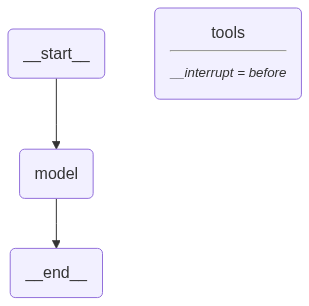

In [2]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
config = {"configurable": {
    "thread_id": 1
}}

events = app.stream({
    "messages": [HumanMessage(content="What is the current weather in Lahore?")]
}, config=config, stream_mode="values")

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

What is the current weather in Chennai?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (3b8nkgm7r)
 Call ID: 3b8nkgm7r
  Args:
    query: current weather in Chennai


In [4]:
snapshot = app.get_state(config=config)
snapshot.next

('tools',)

In [5]:
events = app.stream(None, config, stream_mode="values")
for event in events:
    event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (3b8nkgm7r)
 Call ID: 3b8nkgm7r
  Args:
    query: current weather in Chennai
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Chennai Weather Today, Chennai Temperature and Air Quality (2026-08-01) - India Today", "url": "https://www.indiatoday.in/weather/chennai-weather-forecast-today", "content": "Go Ad-Free with India Today\n\nEnjoy uninterrupted reading with an ad-free experience for just ₹31/month. Cancel anytime.\n\n07/31/2026 | 08:10:00 PM IST\n\n India Today\n Aaj Tak\n India Today Hindi\n NewsTak\n GNTTV\n Lallantop\n Business Today\n Bangla\n Malayalam\n\n Northeast\n BT Bazaar\n Harper's Bazaar\n Sports Tak\n Astro Tak\n Gaming\n Brides Today\n Cosmopolitan\n Kisan Tak\n Reader’s Digest\n\nMagazine\n\nLive TV\n\n### TRENDING TOPICS\n\nSIGN IN\n\nEdition\n\nIN\n\n IN\n US\n\nUnl